In [58]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [59]:
covid_path = r"C:\Users\Kaviya S\covid\images_covid"
normal_path = r"C:\Users\Kaviya S\covid\images_normal"

In [60]:
IMG_SIZE=(150,150)
BATCH_SIZE=32

In [61]:
import glob

covid_images = glob.glob(covid_path + r"\*.png")
print("Number of COVID images:", len(covid_images))

normal_images = glob.glob(normal_path + r"\*.png")
print("Number of Normal images:", len(normal_images))

Number of COVID images: 3678
Number of Normal images: 62


In [62]:
import pandas as pd

covid_df = pd.DataFrame({"filename": covid_images, "label": 1})
normal_df = pd.DataFrame({"filename": normal_images, "label": 0})
df = pd.concat([covid_df, normal_df], ignore_index=True)

In [63]:
print("\nDataset Shape:")
print(df.shape)
print("\nFirst 5 Records:")
print(df.head())
print("\nLast 5 Records:")
print(df.tail())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Records:")
print(df.duplicated().sum())
print(df.drop_duplicates())


Dataset Shape:
(3740, 2)

First 5 Records:
                                            filename  label
0   C:\Users\Kaviya S\covid\images_covid\COVID-1.png      1
1  C:\Users\Kaviya S\covid\images_covid\COVID-10.png      1
2  C:\Users\Kaviya S\covid\images_covid\COVID-100...      1
3  C:\Users\Kaviya S\covid\images_covid\COVID-100...      1
4  C:\Users\Kaviya S\covid\images_covid\COVID-100...      1

Last 5 Records:
                                               filename  label
3735  C:\Users\Kaviya S\covid\images_normal\Normal-1...      0
3736  C:\Users\Kaviya S\covid\images_normal\Normal-1...      0
3737  C:\Users\Kaviya S\covid\images_normal\Normal-1...      0
3738  C:\Users\Kaviya S\covid\images_normal\Normal-1...      0
3739  C:\Users\Kaviya S\covid\images_normal\Normal-1...      0

Missing Values:
filename    0
label       0
dtype: int64

Duplicate Records:
0
                                               filename  label
0      C:\Users\Kaviya S\covid\images_covid\COVID-1.png   

In [64]:
print("\nClass Distribution:")
print(df["label"].value_counts())
print("\nClass Names:")
print(df["label"].value_counts().rename(index={0: "NORMAL",1: "COVID"}))


Class Distribution:
label
1    3678
0      62
Name: count, dtype: int64

Class Names:
label
COVID     3678
NORMAL      62
Name: count, dtype: int64


In [65]:
# SHUFFLE DATA
df = df.sample(frac=1,random_state=42
).reset_index(drop=True)

train_df, test_df = train_test_split(df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"])

print("\nTraining Images:",len(train_df))
print("Testing Images:",len(test_df))


Training Images: 2992
Testing Images: 748


In [66]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.20)

In [67]:
test_datagen = ImageDataGenerator(
    rescale=1./255)

In [68]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filename",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    subset="training",
    shuffle=True)

Found 2394 validated image filenames.


In [69]:
validation_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filename",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    subset="validation",
    shuffle=False)



Found 598 validated image filenames.


In [70]:
test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col="filename",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False)

# DISPLAY GENERATOR INFORMATION
print("\nTraining Samples:",train_generator.samples)
print("Validation Samples:",validation_generator.samples)
print("Testing Samples:",test_generator.samples)

Found 748 validated image filenames.

Training Samples: 2394
Validation Samples: 598
Testing Samples: 748


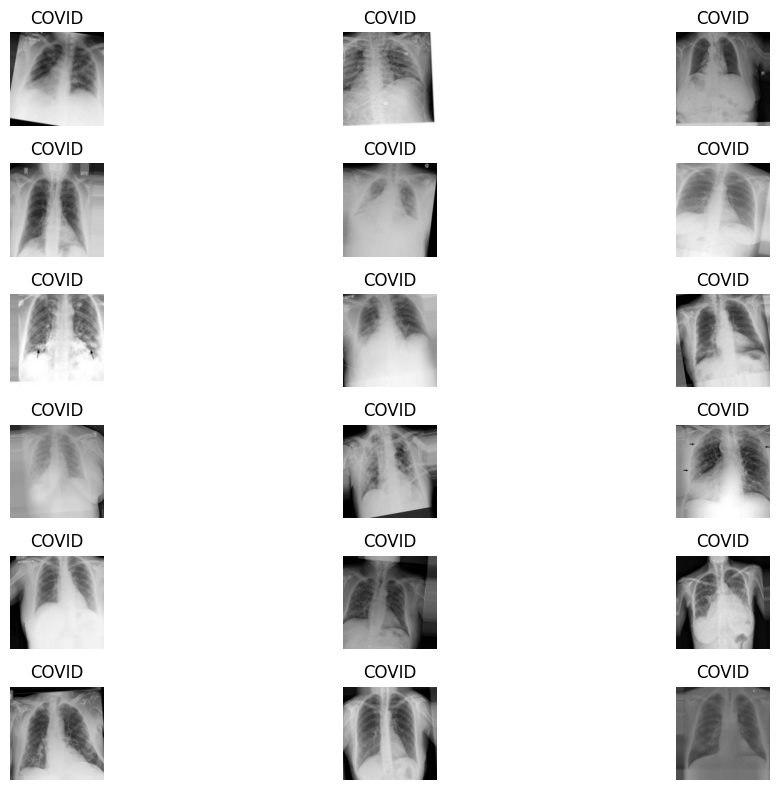

In [71]:
images, labels = next(train_generator)

plt.figure(figsize=(12,8))

for i in range(18):
    plt.subplot(6,3,i+1)
    plt.imshow(images[i])
    
    if labels[i] == 1:
        plt.title("COVID")
    else:
        plt.title("NORMAL")
        
    plt.axis("off")

plt.tight_layout()
plt.show()

In [72]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(224,224,3)),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.summary()

model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

C:\Users\Kaviya S\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 394272)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │      50,466,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 50,467,969 (192.52 MB)

 Trainable params: 50,467,969 (192.52 MB)

 Non-trainable params: 0 (0.00 B)

In [73]:
model = Sequential([
    Conv2D(32,(3,3),activation="relu",input_shape=(150,150,3)),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128,activation="relu"),
    Dense(1,activation="sigmoid")
])

model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

test_generator.reset()
predictions = model.predict(test_generator)
predicted_classes = (predictions >= 0.5).astype(int).flatten()

24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 184ms/step


In [74]:
image_path = covid_images[0]
print("Image Used:", image_path)

img = tf.keras.utils.load_img(image_path, target_size=(150,150))
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

Image Used: C:\Users\Kaviya S\covid\images_covid\COVID-1.png


In [75]:
prediction = model.predict(img_array)
probability = prediction[0][0]

print("Prediction Probability:", probability)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
Prediction Probability: 0.4116986


Prediction: NORMAL


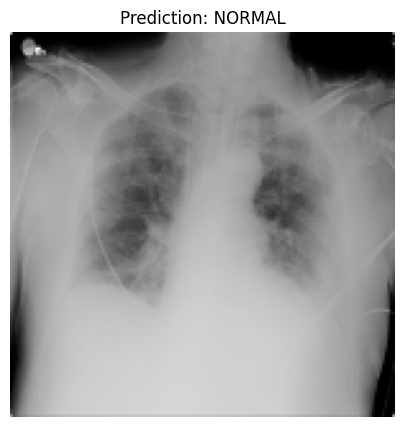

In [76]:
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")

if probability >= 0.5:
    print("Prediction: COVID")
    plt.title("Prediction: COVID")
else:
    print("Prediction: NORMAL")
    plt.title("Prediction: NORMAL")

plt.show()

In [77]:
print("Actual Label: COVID")
print("Predicted Label:", "COVID" if probability >= 0.5 else "NORMAL")

Actual Label: COVID
Predicted Label: NORMAL
